In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Reading and checking the dataset**

In [2]:
df=pd.read_csv("netflix.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


**To see all columns**

In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

**Renaming the listed in column to genres**

In [4]:
df.rename(columns={'listed_in':'genre'},inplace=True)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

**Dropping the show_id column as it may be of no use in the analysis**

In [5]:
df.drop('show_id',axis=1,inplace=True)
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

**Checking for duplicates**

In [6]:
df.duplicated().sum()

np.int64(0)

**Checking the missing values**

In [7]:
df.isna().sum()   # another way df.isnull().sum()

,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
genre,0


**Dropping the rows which have null values in date_added column as there are only 10 values**

In [8]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()


np.int64(0)

**Dropping the rows which have null values in rating column as there are only 4 values**

In [9]:
df.dropna(subset=['rating'],inplace=True)
df['rating'].isna().sum()

np.int64(0)

**Dropping the rows which have null values in duration column as there are only 3 values**

In [10]:
df=df.dropna(subset=['duration'])
df['duration'].isna().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
type,0
title,0
director,2621
cast,825
country,829
date_added,0
release_year,0
rating,0
duration,0
genre,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      6169 non-null   object
 3   cast          7965 non-null   object
 4   country       7961 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   genre         8790 non-null   object
 10  description   8790 non-null   object
dtypes: int64(1), object(10)
memory usage: 824.1+ KB


** When there is some mismatch in our date format then that values is replaced by null**

In [13]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_added'].isna().sum()


/tmp/ipykernel_1866/2359665471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')


np.int64(88)

In [14]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

/tmp/ipykernel_1866/817333644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['date_added'],inplace=True)


np.int64(0)

**Adding day, month, year, month_name,day_name as seprated columns**

In [15]:
df['day']=df['date_added'].dt.day
df['month']=df['date_added'].dt.month
df['year']=df['date_added'].dt.year
df['month_name']=df['date_added'].dt.month_name()
df['weekday']=df['date_added'].dt.day_name()
df.head()

/tmp/ipykernel_1866/3694861535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day']=df['date_added'].dt.day
/tmp/ipykernel_1866/3694861535.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month']=df['date_added'].dt.month
/tmp/ipykernel_1866/3694861535.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [16]:
df['duration'].unique()


array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [17]:
s1='90 min'
int(s1.split()[0])

90

In [18]:
s1='13 Seasons'
int(s1.split()[0])

13

In [19]:
df['duration']=df['duration'].apply(lambda x:int(x.split()[0]))
df['duration'].unique()

/tmp/ipykernel_1866/1106310186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration']=df['duration'].apply(lambda x:int(x.split()[0]))


array([ 90,   2,   1,  91, 125,   9, 104, 127,   4,  67,  94,   5, 161,
        61, 166, 147, 103,  97, 106, 111,   3, 110, 105,  96, 124, 116,
        98,  23, 115, 122,  99,  88, 100,   6, 102,  93,  95,  85,  83,
       113,  13, 182,  48, 145,  87,  92,  80, 117, 128, 119, 143, 114,
       118, 108,  63, 121, 142, 154, 120,  82, 109, 101,  86, 229,  76,
        89, 156, 112, 107, 129, 135, 136, 165, 150, 133,  70,  84, 140,
        78,   7,  64,  59, 139,  69, 148, 189, 141, 130, 138,  81, 132,
        10, 123,  65,  68,  66,  62,  74, 131,  39,  46,  38,   8,  17,
       126, 155, 159, 137,  12, 273,  36,  34,  77,  60,  49,  58,  72,
       204, 212,  25,  73,  29,  47,  32,  35,  71, 149,  33,  15,  54,
       224, 162,  37,  75,  79,  55, 158, 164, 173, 181, 185,  21,  24,
        51, 151,  42,  22, 134, 177,  52,  14,  53,  57,  28,  50,  26,
        45, 171,  27,  44, 146,  20, 157, 203,  41,  30, 194, 233, 237,
       230, 195, 253, 152, 190, 160, 208, 180, 144, 174, 170, 19

**Checking for unique values of rating and categorising them for better understanding**

In [20]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [21]:
df['rating']=df['rating'].replace(['TV-Y','TV-Y7',"G",'TV-G','PG','TV-PG','TV-Y7-FV'],'kids')
df['rating']=df['rating'].replace(['PG-13','TV-14'],'teens')
df['rating']=df['rating'].replace(['R','TV-MA','NC', 'NC-17'],'adults')
df['rating']=df['rating'].replace(['NR','UR'],np.nan)
df


/tmp/ipykernel_1866/4171577002.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rating']=df['rating'].replace(['TV-Y','TV-Y7',"G",'TV-G','PG','TV-PG','TV-Y7-FV'],'kids')
/tmp/ipykernel_1866/4171577002.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rating']=df['rating'].replace(['PG-13','TV-14'],'teens')
/tmp/ipykernel_1866/4171577002.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,adults,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,adults,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,adults,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,adults,158,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",20,11,2019,November,Wednesday
8803,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,kids,2,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",1,7,2019,July,Monday
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,adults,88,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,1,11,2019,November,Friday
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,kids,88,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",11,1,2020,January,Saturday


In [22]:
df['rating'].unique()

array(['teens', 'adults', 'kids', nan], dtype=object)

In [23]:
df['rating'].isnull().sum()

np.int64(81)

In [24]:
df.dropna(subset=['rating'],inplace=True)


/tmp/ipykernel_1866/1044244190.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['rating'],inplace=True)


In [25]:
df['rating'].isnull().sum()

np.int64(0)

In [26]:
df.isna().sum()

,0
type,0
title,0
director,2535
cast,800
country,826
date_added,0
release_year,0
rating,0
duration,0
genre,0


**Now we still have about 48% missing data .So, we will check in which rows the director, country and cast all three are null, if all these 3 are null then there is no use of that row**

In [27]:
df[(df['director'].isna())&(df['country'].isna())&(df['cast'].isna())]

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,adults,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
10,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,2021-09-24,2021,adults,1,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B...",24,9,2021,September,Friday
14,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,2021-09-22,2021,adults,1,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...,22,9,2021,September,Wednesday
74,TV Show,The World's Most Amazing Vacation Rentals,NaN,NaN,NaN,2021-09-14,2021,kids,2,Reality TV,"With an eye for every budget, three travelers ...",14,9,2021,September,Tuesday
123,TV Show,Luv Kushh,NaN,NaN,NaN,2021-09-02,2012,kids,1,Kids' TV,"Based on the last book of the epic Ramayana, t...",2,9,2021,September,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7812,TV Show,Queens of Comedy,NaN,NaN,NaN,2018-05-01,2017,adults,1,"International TV Shows, Stand-Up Comedy & Talk...",Eight women perform in front of celebrity judg...,1,5,2018,May,Tuesday
8109,TV Show,Strongland,NaN,NaN,NaN,2019-01-18,2018,kids,1,"Docuseries, International TV Shows",From Spain's countryside to Scotland's stony t...,18,1,2019,January,Friday
8199,TV Show,The Bachelor,NaN,NaN,NaN,2019-12-01,2009,teens,1,"Reality TV, Romantic TV Shows",A single man searches for his soulmate through...,1,12,2019,December,Sunday
8609,TV Show,Towies,NaN,NaN,NaN,2017-12-27,2016,adults,1,"International TV Shows, Reality TV",Australia's toughest tow truck operators work ...,27,12,2017,December,Wednesday


In [28]:
df[(df['director'].isna())&(df['country'].isna())&(df['cast'].isna())].shape[0]

96

**We found out that total 96 such rows are there which dont have director,country and cast as null,so deleting those rows**

In [29]:
df.shape

(8621, 16)

In [30]:
df.dropna(subset=['director','country','cast'],how='all',inplace=True) #how=all stands for deleting only those rows which has null in all three columns director,country,cast
df.shape

/tmp/ipykernel_1866/1191777066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['director','country','cast'],how='all',inplace=True) #how=all stands for deleting only those rows which has null in all three columns director,country,cast


(8525, 16)

In [31]:
df.isna().sum()

,0
type,0
title,0
director,2439
cast,704
country,730
date_added,0
release_year,0
rating,0
duration,0
genre,0


In [32]:
df['cast'][2].split(', ')

['Sami Bouajila',
 'Tracy Gotoas',
 'Samuel Jouy',
 'Nabiha Akkari',
 'Sofia Lesaffre',
 'Salim Kechiouche',
 'Noureddine Farihi',
 'Geert Van Rampelberg',
 'Bakary Diombera']

In [33]:
df_cast=pd.DataFrame(df['cast'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [34]:
df_cast=df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 63644, dtype: object

In [35]:
df_cast=pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[63644 rows x 1 columns]

In [36]:
df_cast.reset_index(inplace=True) # Title convert back to column
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Blood & Water,0,Ama Qamata
2,Blood & Water,1,Khosi Ngema
3,Blood & Water,2,Gail Mabalane
4,Blood & Water,3,Thabang Molaba
...,...,...,...
63639,Zubaan,3,Manish Chaudhary
63640,Zubaan,4,Meghna Malik
63641,Zubaan,5,Malkeet Rauni
63642,Zubaan,6,Anita Shabdish


In [37]:
df_cast=df_cast[['title',0]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [38]:
df_cast.columns=['title','cast']
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [39]:
df_cast.replace('nan',np.nan,inplace=True)
df_cast.isna().sum()

/tmp/ipykernel_1866/154984155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace('nan',np.nan,inplace=True)


,0
title,0
cast,704


In [40]:
df_genre=pd.DataFrame(df['genre'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_genre=df_genre.stack()
df_genre=pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre=df_genre[['title',0]]
df_genre.columns=['title','genre']
df_genre.replace('nan',np.nan,inplace=True)
df_genre.isna().sum()


,0
title,0
genre,0


In [41]:
df_director=pd.DataFrame(df['director'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_director=df_director.stack()
df_director=pd.DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director=df_director[['title',0]]
df_director.columns=['title','director']
df_director.replace('nan',np.nan,inplace=True)
df_director.isna().sum()

,0
title,0
director,2439


In [42]:
df_country=pd.DataFrame(df['country'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_country=df_country.stack()
df_country=pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country=df_country[['title',0]]
df_country.columns=['title','country']
df_country.replace('nan',np.nan,inplace=True)
df_country.isna().sum()

,0
title,0
country,730


In [43]:
df12=df_cast.merge(df_genre,on='title')
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
146662,Zubaan,Anita Shabdish,International Movies
146663,Zubaan,Anita Shabdish,Music & Musicals
146664,Zubaan,Chittaranjan Tripathy,Dramas
146665,Zubaan,Chittaranjan Tripathy,International Movies


In [44]:
df123=df_director.merge(df12,on='title')
df123


,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
158309,Zubaan,Mozez Singh,Anita Shabdish,International Movies
158310,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
158311,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
158312,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [45]:
df1234=df_country.merge(df123,on='title')
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [46]:
df_new=df1234.merge(df,on='title')
df_new

,title,country_x,director_x,cast_x,genre_x,type,director_y,cast_y,country_y,date_added,release_year,rating,duration,genre_y,description,day,month,year,month_name,weekday
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries,Movie,Kirsten Johnson,NaN,United States,2021-09-25,2020,teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies,Movie,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals,Movie,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas,Movie,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies,Movie,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday


In [47]:
df_new.drop(columns=['country_y','director_y','cast_y','genre_y'],inplace=True)
df_new

,title,country_x,director_x,cast_x,genre_x,type,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries,Movie,2021-09-25,2020,teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday


In [48]:
df_new.rename(columns={'country_x':'country','director_x':'director','cast_x':'cast',"genre_x":"genre"},inplace=True)
df_new

,title,country,director,cast,genre,type,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries,Movie,2021-09-25,2020,teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies,Movie,2019-03-02,2015,teens,111,A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday


In [49]:
df_new.head()

,title,country,director,cast,genre,type,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries,Movie,2021-09-25,2020,teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows,TV Show,2021-09-24,2021,adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday


In [50]:
df_new.shape

(198404, 16)

In [51]:
df_new['cast']=df_new['cast'].replace(np.nan,'unknown')
df_new['director']=df_new['director'].replace(np.nan,'unknown')
df_new['country']=df_new['country'].replace(np.nan,'unknown')
df_new.isna().sum()

,0
title,0
country,0
director,0
cast,0
genre,0
type,0
date_added,0
release_year,0
rating,0
duration,0


In [52]:
df_new.drop(["description"],axis=1,inplace=True)
df_new

,title,country,director,cast,genre,type,date_added,release_year,rating,duration,day,month,year,month_name,weekday
0,Dick Johnson Is Dead,United States,Kirsten Johnson,unknown,Documentaries,Movie,2021-09-25,2020,teens,90,25,9,2021,September,Saturday
1,Blood & Water,South Africa,unknown,Ama Qamata,International TV Shows,TV Show,2021-09-24,2021,adults,2,24,9,2021,September,Friday
2,Blood & Water,South Africa,unknown,Ama Qamata,TV Dramas,TV Show,2021-09-24,2021,adults,2,24,9,2021,September,Friday
3,Blood & Water,South Africa,unknown,Ama Qamata,TV Mysteries,TV Show,2021-09-24,2021,adults,2,24,9,2021,September,Friday
4,Blood & Water,South Africa,unknown,Khosi Ngema,International TV Shows,TV Show,2021-09-24,2021,adults,2,24,9,2021,September,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies,Movie,2019-03-02,2015,teens,111,2,3,2019,March,Saturday
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals,Movie,2019-03-02,2015,teens,111,2,3,2019,March,Saturday
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas,Movie,2019-03-02,2015,teens,111,2,3,2019,March,Saturday
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies,Movie,2019-03-02,2015,teens,111,2,3,2019,March,Saturday


In [53]:
df_new.duplicated().sum()

np.int64(55)

In [54]:
df_movies=df_new[df_new['type']=='Movie']
df_tvs=df_new[df_new['type']=='TV Show']

In [55]:
df_movies.shape

(144295, 15)

In [56]:
df_tvs.shape

(54109, 15)

**Here we are replacing the column duration with a better name season for tv shows only in df_tvs**

In [57]:
df_tvs.rename(columns={'duration':'seasons'},inplace=True)


/tmp/ipykernel_1866/243137724.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns={'duration':'seasons'},inplace=True)


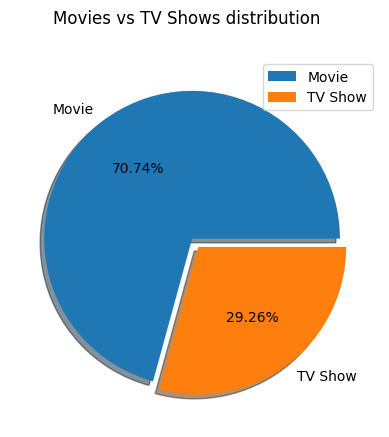

In [58]:
plt.pie(df['type'].value_counts(),labels=df['type'].value_counts().index,autopct='%1.2f%%',
        explode=[0.03,0.04],shadow=True)
plt.suptitle('Movies vs TV Shows distribution')
plt.legend()
plt.show()


# **Let us start visulization**

In [59]:
df_temp=df_new.drop_duplicates(subset=['country','title'])
df_temp

,title,country,director,cast,genre,type,date_added,release_year,rating,duration,day,month,year,month_name,weekday
0,Dick Johnson Is Dead,United States,Kirsten Johnson,unknown,Documentaries,Movie,2021-09-25,2020,teens,90,25,9,2021,September,Saturday
1,Blood & Water,South Africa,unknown,Ama Qamata,International TV Shows,TV Show,2021-09-24,2021,adults,2,24,9,2021,September,Friday
58,Ganglands,unknown,Julien Leclercq,Sami Bouajila,Crime TV Shows,TV Show,2021-09-24,2021,adults,1,24,9,2021,September,Friday
85,Kota Factory,India,unknown,Mayur More,International TV Shows,TV Show,2021-09-24,2021,adults,2,24,9,2021,September,Friday
109,Midnight Mass,unknown,Mike Flanagan,Kate Siegel,TV Dramas,TV Show,2021-09-24,2021,adults,1,24,9,2021,September,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198300,Zinzana,Jordan,Majid Al Ansari,Ali Suliman,Dramas,Movie,2016-03-09,2015,adults,96,9,3,2016,March,Wednesday
198318,Zodiac,United States,David Fincher,Mark Ruffalo,Cult Movies,Movie,2019-11-20,2007,adults,158,20,11,2019,November,Wednesday
198348,Zombieland,United States,Ruben Fleischer,Jesse Eisenberg,Comedies,Movie,2019-11-01,2009,adults,88,1,11,2019,November,Friday
198362,Zoom,United States,Peter Hewitt,Tim Allen,Children & Family Movies,Movie,2020-01-11,2006,kids,88,11,1,2020,January,Saturday


In [60]:
x=df_temp['country'].value_counts().head(10)
x

,count
country,
United States,3596
India,1038
United Kingdom,772
unknown,730
Canada,427
France,383
Japan,313
Spain,228
Germany,223


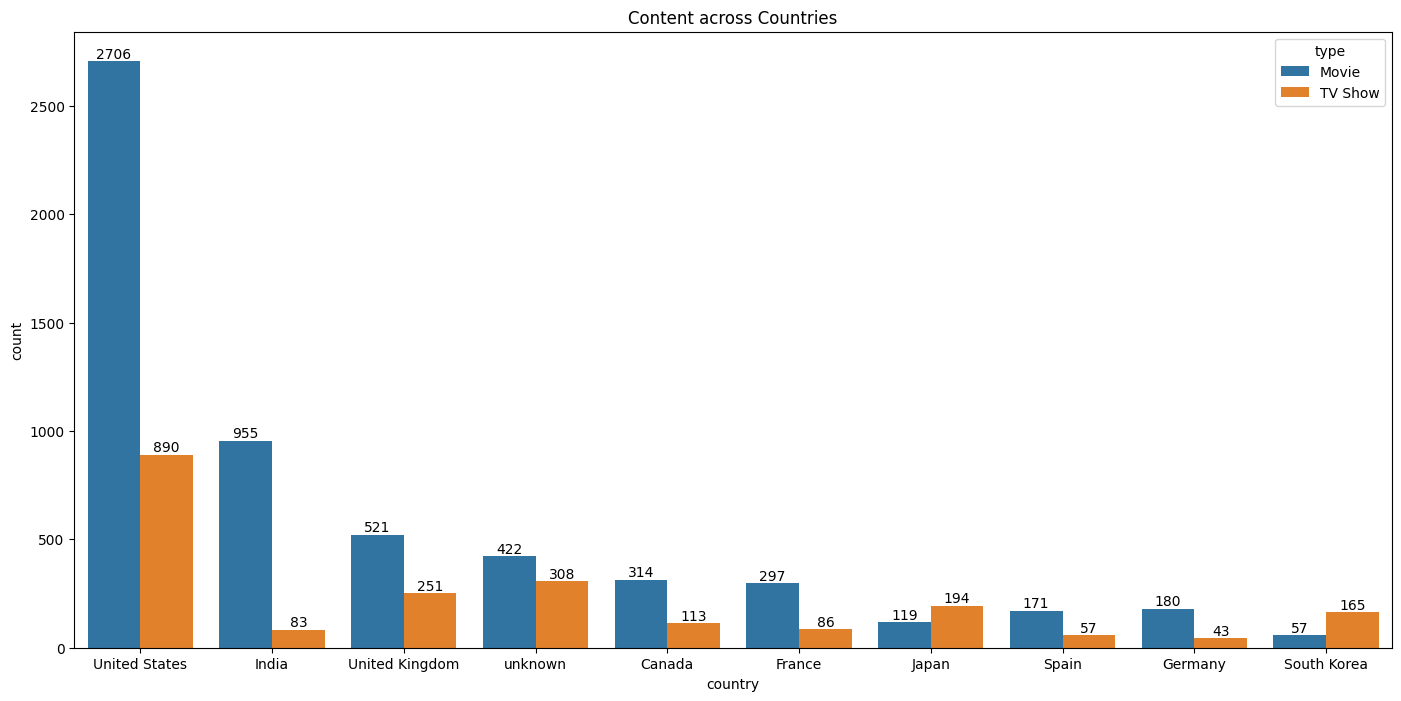

In [61]:
plt.figure(figsize=(17,8))
plt.title('Content across Countries')
label=sns.countplot(data=df_temp,x='country',hue='type',order=x.index)
for i in label.containers:
    label.bar_label(i)
plt.show()

/tmp/ipykernel_1866/1083132654.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='director',order=x.index,palette='plasma')
/tmp/ipykernel_1866/1083132654.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='director',order=y.index,palette='husl')


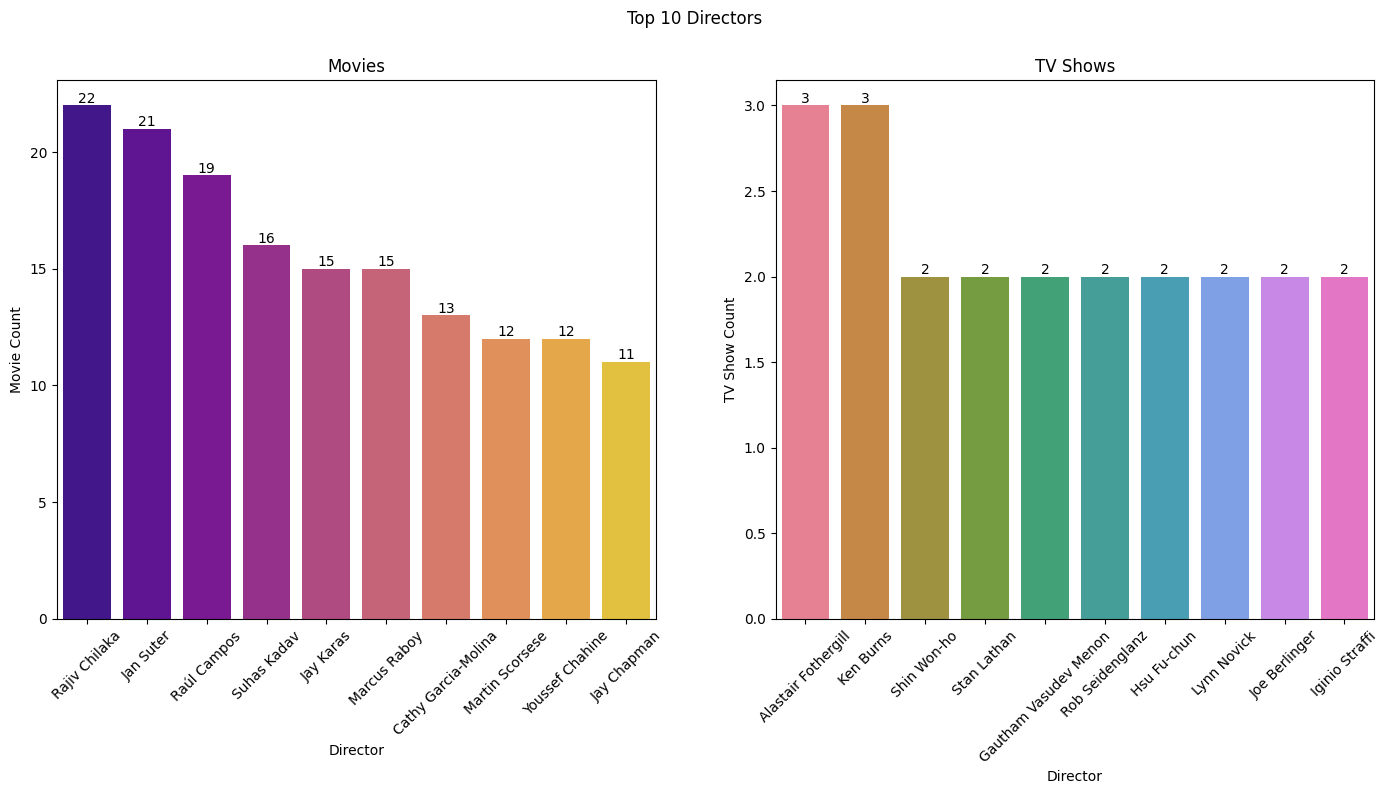

In [62]:
df_movies_temp=df_movies.drop_duplicates(subset=['director','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['director','title'])

plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Directors')
plt.subplot(1,2,1)
x=df_movies_temp['director'].value_counts()[1:11]
label=sns.countplot(data=df_movies_temp,x='director',order=x.index,palette='plasma')
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation=45)
plt.xlabel('Director')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
y=df_tvs_temp['director'].value_counts()[1:11]
label=sns.countplot(data=df_tvs_temp,x='director',order=y.index,palette='husl')
for i in label.containers:
    label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation=45)
plt.xlabel('Director')
plt.ylabel('TV Show Count')
plt.show()


/tmp/ipykernel_1866/270467378.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='genre',order=x.index,palette='plasma')
/tmp/ipykernel_1866/270467378.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='genre',order=y.index,palette='viridis')


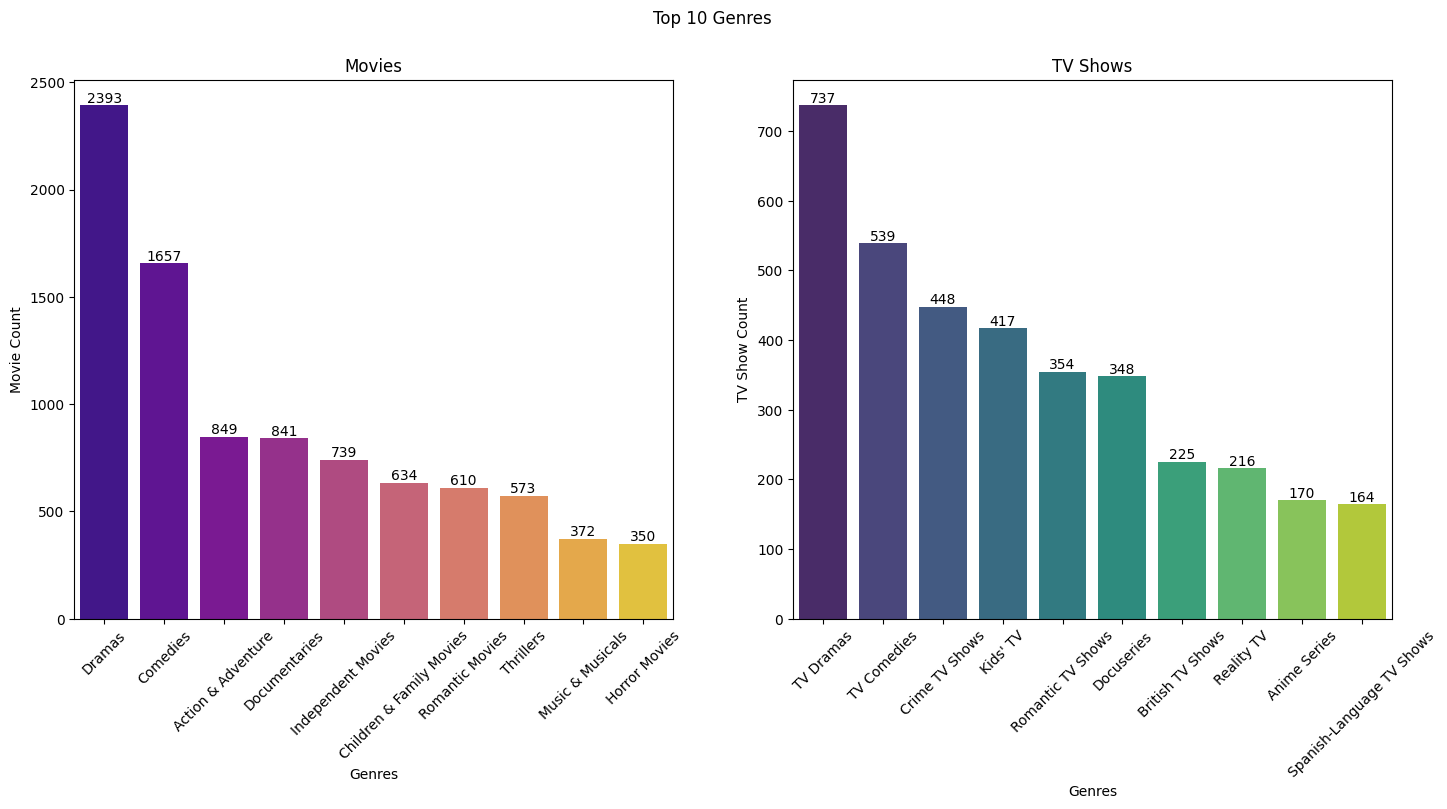

In [63]:
df_movies_temp=df_movies.drop_duplicates(subset=['genre','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['genre','title'])

plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Genres')
plt.subplot(1,2,1)
x=df_movies_temp['genre'].value_counts()[1:11]
label=sns.countplot(data=df_movies_temp,x='genre',order=x.index,palette='plasma')
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
y=df_tvs_temp['genre'].value_counts()[1:11]
label=sns.countplot(data=df_tvs_temp,x='genre',order=y.index,palette='viridis')
for i in label.containers:
    label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('TV Show Count')
plt.show()


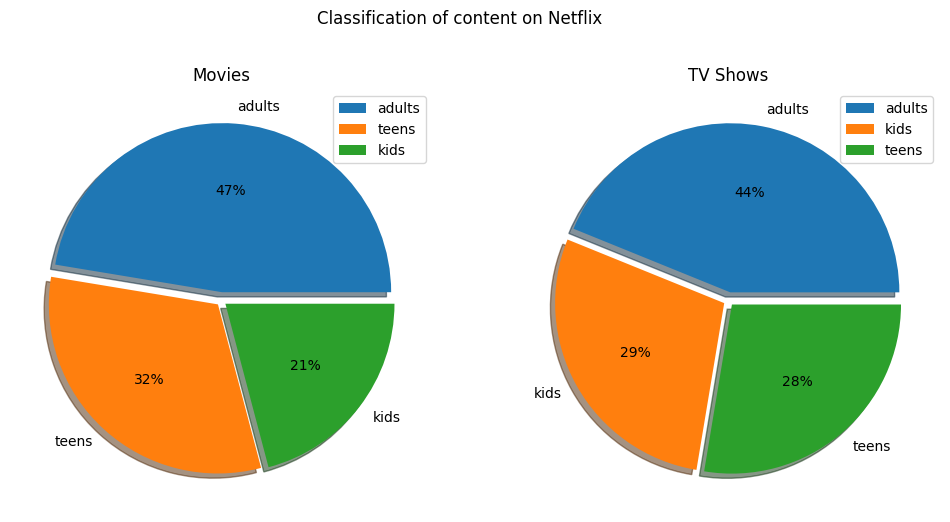

In [64]:
df_movies_temp=df_movies.drop_duplicates(subset=['rating','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['rating','title'])

plt.figure(figsize=(12,6))
plt.suptitle('Classification of content on Netflix')
plt.subplot(1,2,1)
plt.pie(df_movies_temp['rating'].value_counts(),labels=df_movies_temp['rating'].value_counts().index,autopct='%0.0f%%',
        explode=[0.05,0.03,0.03],shadow=True)
plt.title('Movies')
plt.legend()

plt.subplot(1,2,2)
plt.pie(df_tvs_temp['rating'].value_counts(),labels=df_tvs_temp['rating'].value_counts().index,autopct='%0.0f%%',
        explode=[0.05,0.03,0.03],shadow=True)
plt.title('TV Shows')
plt.legend()
plt.show()

In [65]:
df_movies_temp=df_movies.drop_duplicates(subset=['year','title'])
df_movies_temp

,title,country,director,cast,genre,type,date_added,release_year,rating,duration,day,month,year,month_name,weekday
0,Dick Johnson Is Dead,United States,Kirsten Johnson,unknown,Documentaries,Movie,2021-09-25,2020,teens,90,25,9,2021,September,Saturday
157,My Little Pony: A New Generation,unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies,Movie,2021-09-24,2021,kids,91,24,9,2021,September,Friday
177,Sankofa,United States,Haile Gerima,Kofi Ghanaba,Dramas,Movie,2021-09-24,1993,adults,125,24,9,2021,September,Friday
329,The Starling,United States,Theodore Melfi,Melissa McCarthy,Comedies,Movie,2021-09-24,2021,teens,104,24,9,2021,September,Friday
426,Je Suis Karl,Germany,Christian Schwochow,Luna Wedler,Dramas,Movie,2021-09-23,2021,adults,127,23,9,2021,September,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198282,Zinzana,United Arab Emirates,Majid Al Ansari,Ali Suliman,Dramas,Movie,2016-03-09,2015,adults,96,9,3,2016,March,Wednesday
198318,Zodiac,United States,David Fincher,Mark Ruffalo,Cult Movies,Movie,2019-11-20,2007,adults,158,20,11,2019,November,Wednesday
198348,Zombieland,United States,Ruben Fleischer,Jesse Eisenberg,Comedies,Movie,2019-11-01,2009,adults,88,1,11,2019,November,Friday
198362,Zoom,United States,Peter Hewitt,Tim Allen,Children & Family Movies,Movie,2020-01-11,2006,kids,88,11,1,2020,January,Saturday


In [66]:
mv_year=df_movies_temp['year'].value_counts()
mv_year.sort_index(inplace=True)
mv_year

,count
year,
2008,1
2009,2
2011,13
2012,3
2013,3
2014,19
2015,51
2016,224
2017,813


In [67]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
mv_month=df_movies_temp['month_name'].value_counts().loc[month_order]
mv_month

,count
month_name,
January,535
February,375
March,518
April,542
May,433
June,485
July,559
August,515
September,510


In [68]:
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_weekday=df_movies_temp['weekday'].value_counts().loc[day_order]
mv_weekday

,count
weekday,
Monday,612
Tuesday,842
Wednesday,895
Thursday,1040
Friday,1537
Saturday,543
Sunday,562


/tmp/ipykernel_1866/377859066.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='year',order=mv_year.index,palette='husl')
/tmp/ipykernel_1866/377859066.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='month_name',order=mv_month.index,palette='plasma')
/tmp/ipykernel_1866/377859066.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='weekday',order=mv_weekday.index,palette='viridis')


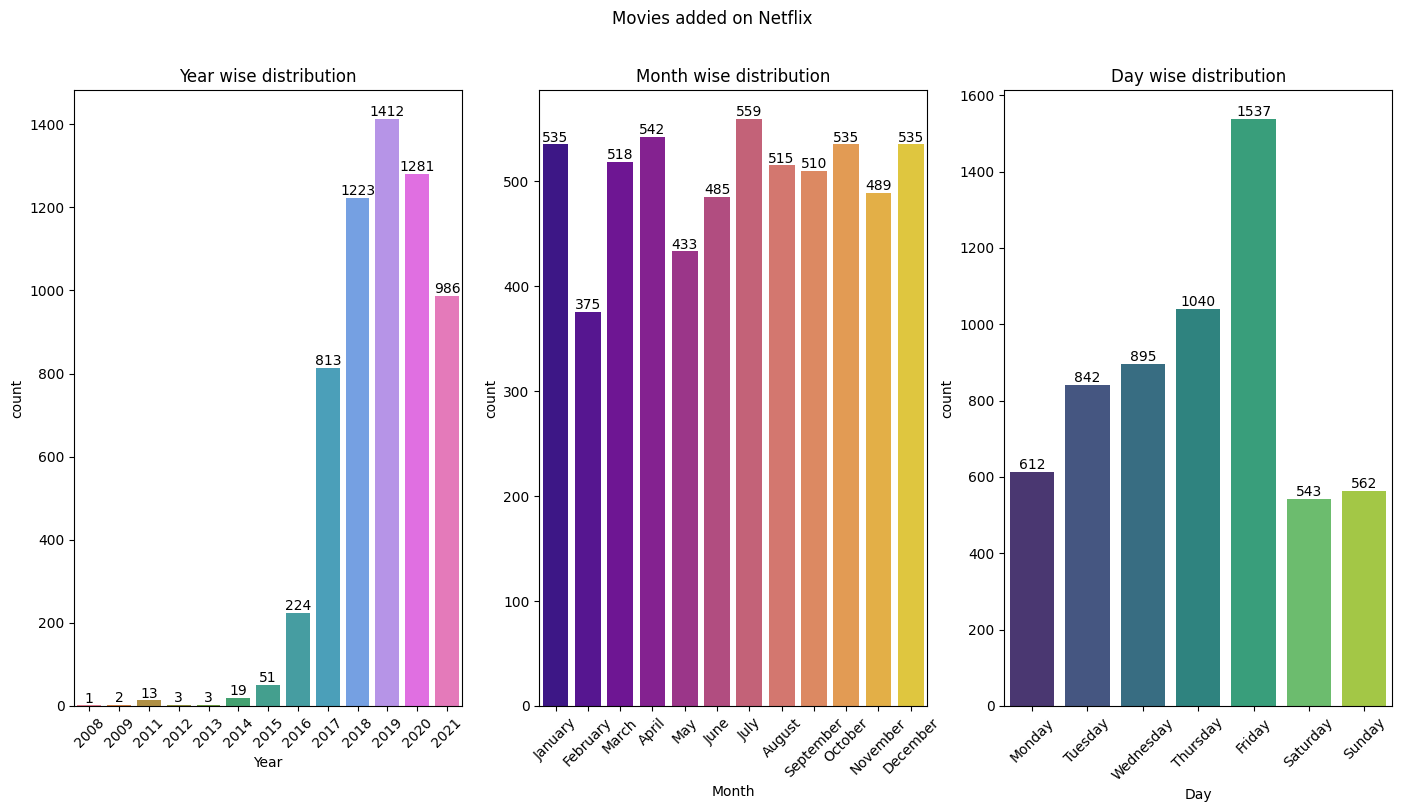

In [69]:
plt.figure(figsize=(17,8))
plt.suptitle('Movies added on Netflix')

plt.subplot(1,3,1)
label=sns.countplot(data=df_movies_temp,x='year',order=mv_year.index,palette='husl')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.title('Year wise distribution')

plt.subplot(1,3,2)
label=sns.countplot(data=df_movies_temp,x='month_name',order=mv_month.index,palette='plasma')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Month wise distribution')

plt.subplot(1,3,3)
label=sns.countplot(data=df_movies_temp,x='weekday',order=mv_weekday.index,palette='viridis')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Day')
plt.title('Day wise distribution')
plt.show()


/tmp/ipykernel_1866/1597255229.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='year',order=tv_year.index,palette='husl')
/tmp/ipykernel_1866/1597255229.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='month_name',order=tv_month.index,palette='plasma')
/tmp/ipykernel_1866/1597255229.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='weekday',order=tv_weekday.index,palette='viridis')


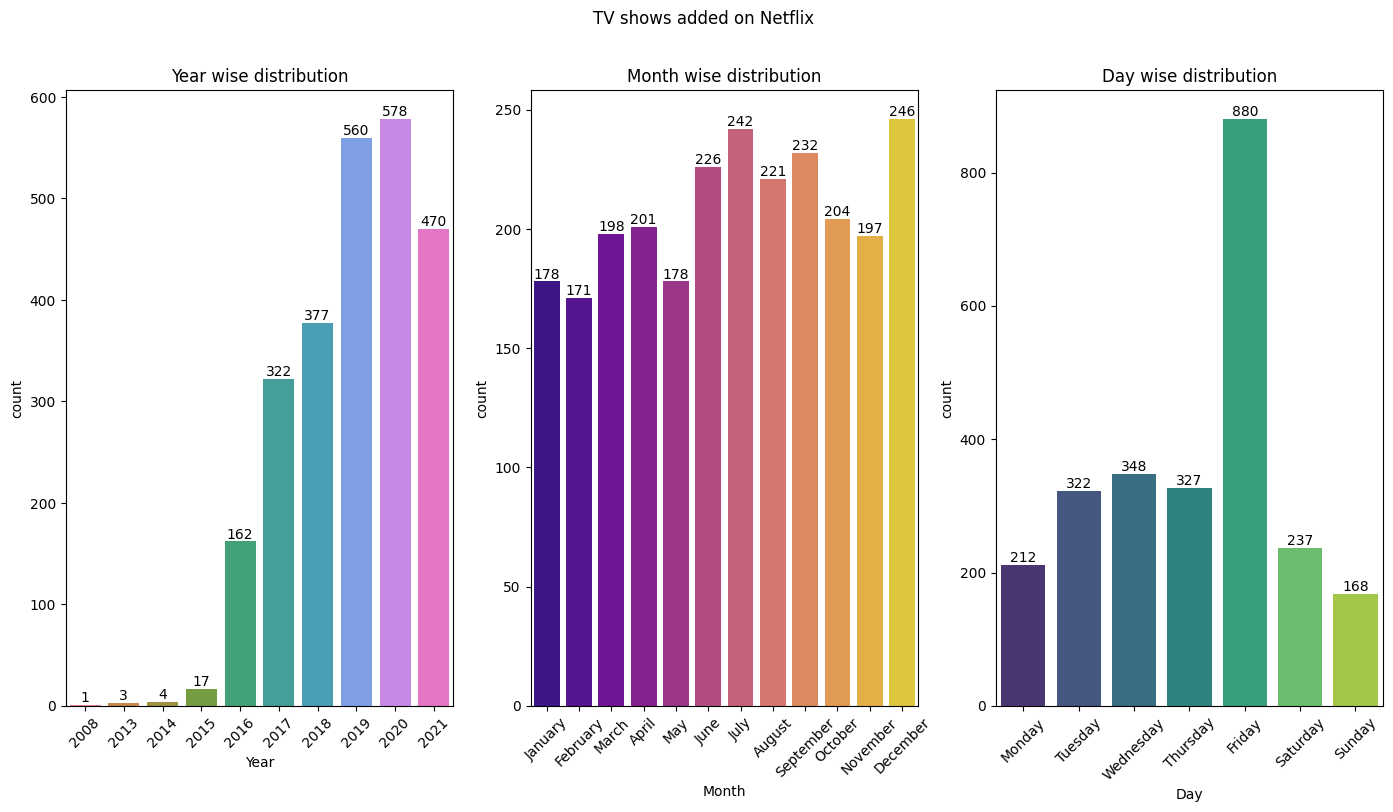

In [70]:
df_tvs_temp=df_tvs.drop_duplicates(subset=['year','title'])

tv_year=df_tvs_temp['year'].value_counts()
tv_year.sort_index(inplace=True)

month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
tv_month=df_tvs_temp['month_name'].value_counts().loc[month_order]

day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tv_weekday=df_movies_temp['weekday'].value_counts().loc[day_order]

plt.figure(figsize=(17,8))
plt.suptitle('TV shows added on Netflix')

plt.subplot(1,3,1)
label=sns.countplot(data=df_tvs_temp,x='year',order=tv_year.index,palette='husl')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.title('Year wise distribution')

plt.subplot(1,3,2)
label=sns.countplot(data=df_tvs_temp,x='month_name',order=tv_month.index,palette='plasma')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.title('Month wise distribution')

plt.subplot(1,3,3)
label=sns.countplot(data=df_tvs_temp,x='weekday',order=tv_weekday.index,palette='viridis')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel('Day')
plt.title('Day wise distribution')
plt.show()


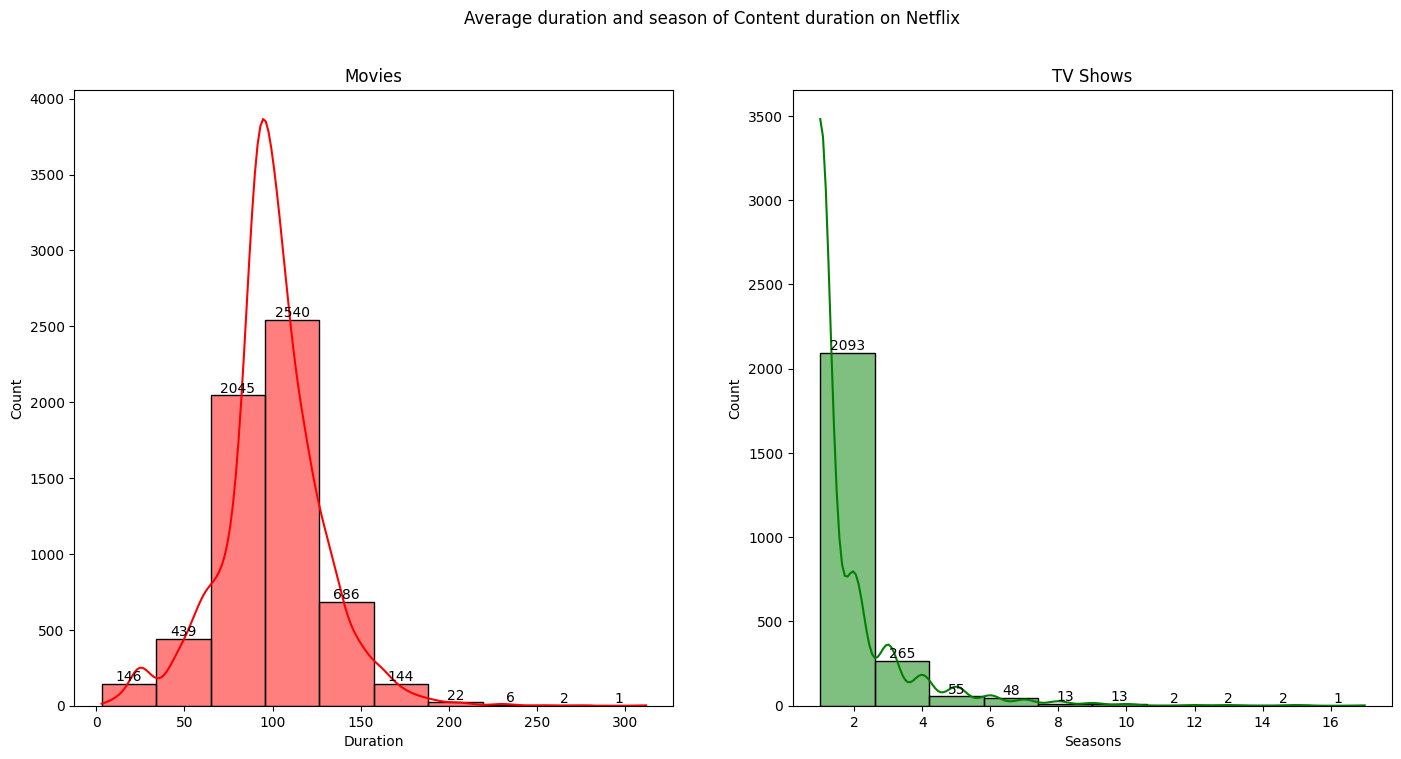

In [71]:
df_movies_temp=df_movies.drop_duplicates(subset=['duration','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['seasons','title'])

plt.figure(figsize=(17,8))
plt.suptitle('Average duration and season of Content duration on Netflix')

plt.subplot(1,2,1)
label=sns.histplot(df_movies_temp['duration'],bins=10,color='red',kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Duration')
plt.title('Movies')

plt.subplot(1,2,2)
label=sns.histplot(data=df_tvs_temp,x='seasons',bins=10,color='g',kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Seasons')
plt.title('TV Shows')
plt.show()

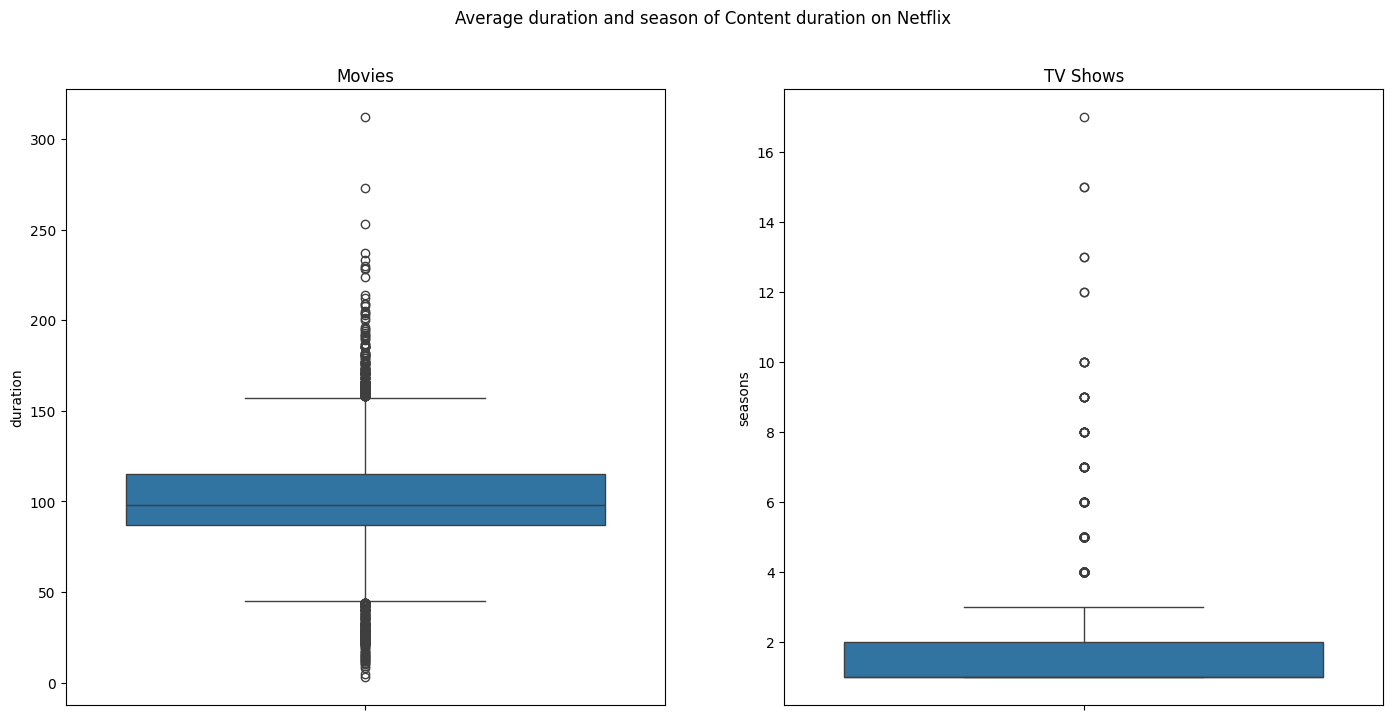

In [72]:
plt.figure(figsize=(17,8))
plt.suptitle('Average duration and season of Content duration on Netflix')

plt.subplot(1,2,1)
sns.boxplot(y=df_movies_temp['duration'])
plt.title('Movies')

plt.subplot(1,2,2)
sns.boxplot(y=df_tvs_temp['seasons'])
plt.title('TV Shows')
plt.show()

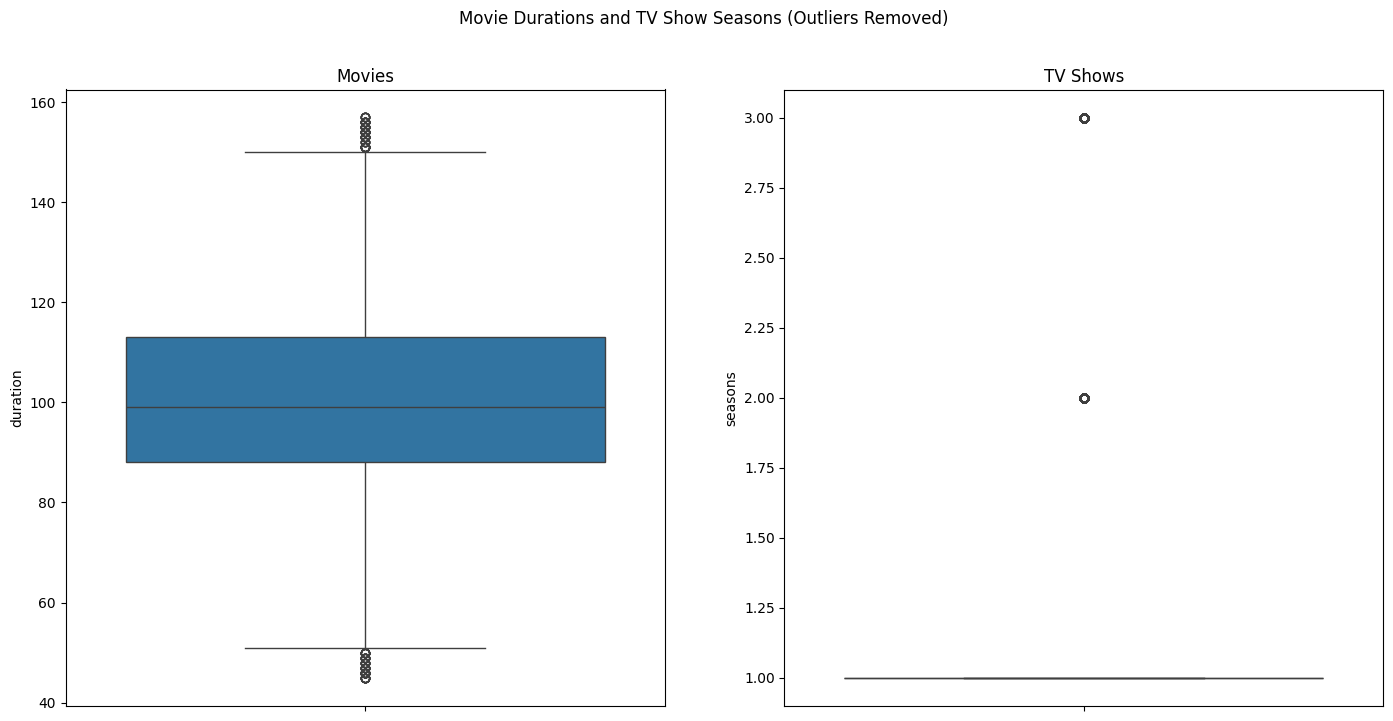

In [73]:
def remove_outliers(df_col):
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df_col[(df_col >= lower) & (df_col <= upper)]

movies_duration_clean = remove_outliers(df_movies_temp['duration'])
tv_seasons_clean = remove_outliers(df_tvs_temp['seasons'])

plt.figure(figsize=(17,8))
plt.suptitle('Movie Durations and TV Show Seasons (Outliers Removed)')

plt.subplot(1,2,1)
sns.boxplot(y=movies_duration_clean)
plt.title('Movies')

plt.subplot(1,2,2)
sns.boxplot(y=tv_seasons_clean)
plt.title('TV Shows')

plt.show()

/tmp/ipykernel_1866/870838510.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='cast',order=x.index,palette='plasma')
/tmp/ipykernel_1866/870838510.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='cast',order=y.index,palette='viridis')


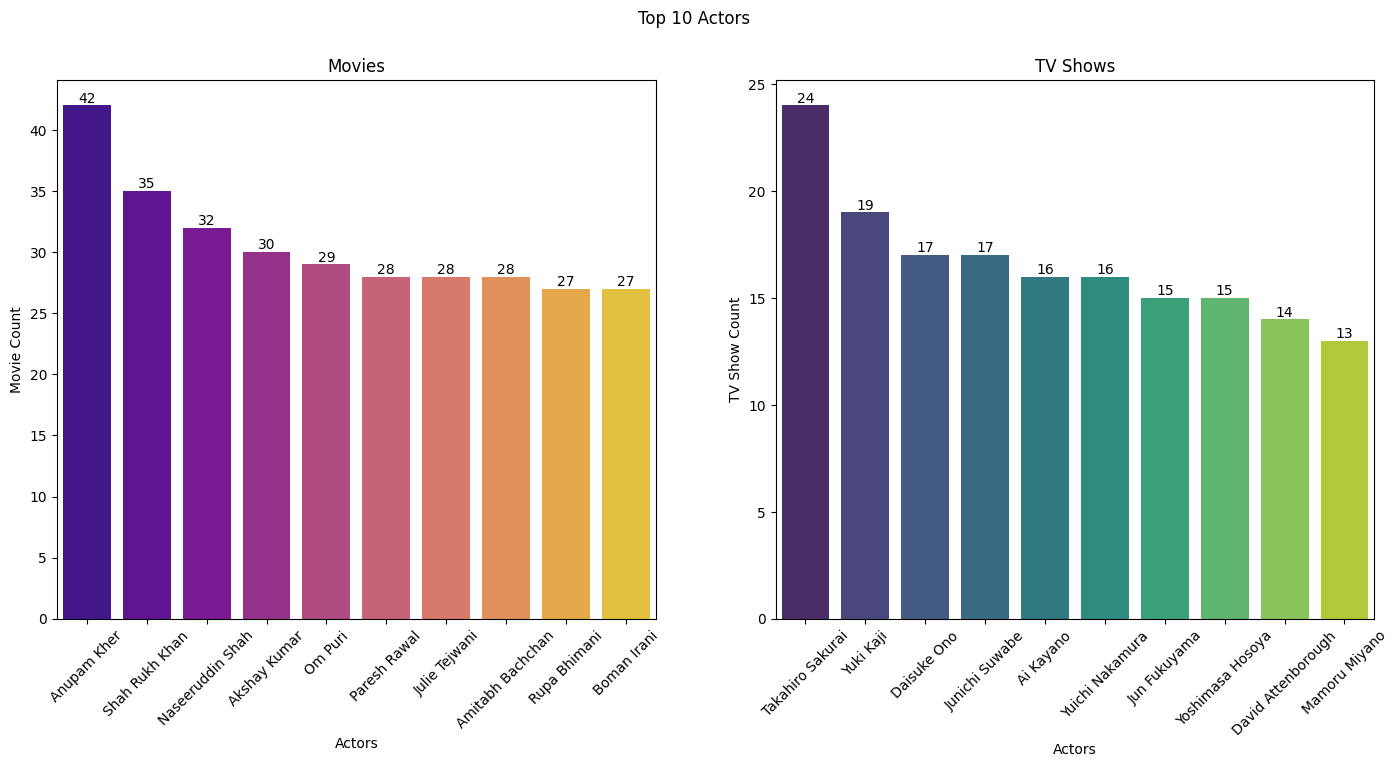

In [74]:
df_movies_temp=df_movies.drop_duplicates(subset=['cast','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['cast','title'])

plt.figure(figsize=(17,7))
plt.suptitle('Top 10 Actors')
plt.subplot(1,2,1)
x=df_movies_temp['cast'].value_counts()[1:11]
label=sns.countplot(data=df_movies_temp,x='cast',order=x.index,palette='plasma')
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation=45)
plt.xlabel('Actors')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
y=df_tvs_temp['cast'].value_counts()[1:11]
label=sns.countplot(data=df_tvs_temp,x='cast',order=y.index,palette='viridis')
for i in label.containers:
    label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation=45)
plt.xlabel('Actors')
plt.ylabel('TV Show Count')
plt.show()
